# EDA и аудит данных — Drop Forecaster

**Цель:** Исследовать историю тендеров для прогнозирования снижения цены (`drop_fraction`).

**Содержание:**
1. Загрузка данных
2. Описательная статистика
3. Анализ пропусков и аномалий
4. Распределение целевой переменной
5. Корреляции и зависимости
6. Выводы и рекомендации

In [1]:
import os
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройки визуализации
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('viridis')

print('Библиотеки загружены ✓')

Библиотеки загружены ✓


## 1. Загрузка данных

Загружаем датасет из локального файла `data/history_drop_dataset.csv`.

In [2]:
DATA_PATH = os.path.join('..', 'data', 'history_drop_dataset.csv')
df = pd.read_csv(DATA_PATH)
print(f'Файл: {DATA_PATH}')
print(f'Размер датасета: {df.shape}')
print(f'Колонки: {list(df.columns)}')
df.head(10)

Файл: ../data/history_drop_dataset.csv
Размер датасета: (5000, 10)
Колонки: ['customer_inn', 'region', 'fz_type', 'procedure_type', 'nmck_rub', 'participants_count_est', 'nmck_log1p', 'drop_fraction', 'customer_avg_drop', 'customer_contracts_count']


,customer_inn,region,fz_type,procedure_type,nmck_rub,participants_count_est,nmck_log1p,drop_fraction,customer_avg_drop,customer_contracts_count
0,7702370808,Новосибирская область,223-ФЗ,Закупка у единственного поставщика,17329.99,3,9.760252,0.0399,0.080426,21
1,7702257772,Московская область,44-ФЗ,Закупка у единственного поставщика,152875.83,4,11.937388,0.0100,0.112129,24
2,7704930456,Краснодарский край,44-ФЗ,Электронный аукцион,31714.00,7,10.364545,0.1410,0.125471,19
3,7708242878,г. Москва,223-ФЗ,Электронный аукцион,33258.53,5,10.412097,0.1040,0.104011,22
4,7705200488,г. Москва,223-ФЗ,Запрос котировок,545611.21,6,13.209664,0.1282,0.135405,22
5,7709258868,Новосибирская область,223-ФЗ,Открытый конкурс,1156938.78,4,13.961289,0.1090,0.134562,32
6,7704256313,г. Москва,44-ФЗ,Закупка у единственного поставщика,417805.69,5,12.942774,0.0532,0.120544,26
7,7704275153,Новосибирская область,44-ФЗ,Электронный аукцион,180263.89,1,12.102183,0.0565,0.131240,30
8,7706957247,г. Санкт-Петербург,223-ФЗ,Запрос предложений,80391.63,7,11.294678,0.1468,0.103180,24
9,7704275153,Челябинская область,223-ФЗ,Открытый конкурс,249959.11,4,12.429057,0.0440,0.117538,30


## 2. Описательная статистика

In [3]:
# Числовые статистики
df.describe().round(4)

,customer_inn,nmck_rub,participants_count_est,nmck_log1p,drop_fraction,customer_avg_drop,customer_contracts_count
count,5.000000e+03,5.000000e+03,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000
mean,7.705562e+09,2.225246e+06,5.0404,13.0570,0.1153,0.1153,25.9604
std,2.484847e+06,7.485746e+06,2.0316,1.8059,0.0504,0.0144,4.8660
min,7.701066e+09,5.667000e+02,1.0000,6.3416,0.0000,0.0565,12.0000
25%,7.703532e+09,1.348266e+05,4.0000,11.8118,0.0823,0.1057,22.0000
50%,7.705480e+09,4.679506e+05,5.0000,13.0561,0.1163,0.1153,26.0000
75%,7.707850e+09,1.583924e+06,6.0000,14.2754,0.1490,0.1250,29.0000
max,7.709965e+09,2.666515e+08,14.0000,19.4015,0.3028,0.1736,38.0000


In [4]:
# Категориальные переменные
cat_cols = ['region', 'fz_type', 'procedure_type']
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())


--- region ---
region
г. Москва                1284
г. Санкт-Петербург        763
Московская область        598
Свердловская область      404
Новосибирская область     365
Республика Татарстан      347
Челябинская область       340
Краснодарский край        328
Красноярский край         297
Нижегородская область     274
Name: count, dtype: int64

--- fz_type ---
fz_type
44-ФЗ     3514
223-ФЗ    1486
Name: count, dtype: int64

--- procedure_type ---
procedure_type
Электронный аукцион                   2697
Открытый конкурс                       765
Запрос котировок                       620
Закупка у единственного поставщика     512
Запрос предложений                     406
Name: count, dtype: int64


## 3. Анализ пропусков и аномалий

In [5]:
# Пропуски
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Пропуски': missing, '%': missing_pct})
print('Пропуски в данных:')
missing_df[missing_df['Пропуски'] > 0] if missing.sum() > 0 else print('Пропусков нет ✓')

Пропуски в данных:
Пропусков нет ✓


In [6]:
# Дубликаты
dups = df.duplicated().sum()
print(f'Дубликатов: {dups} ({dups/len(df)*100:.2f}%)')

Дубликатов: 0 (0.00%)


In [7]:
# Выбросы по IQR для числовых колонок
num_cols = ['nmck_rub', 'participants_count_est', 'drop_fraction', 'customer_avg_drop']
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {outliers} выбросов ({outliers/len(df)*100:.1f}%)')

nmck_rub: 620 выбросов (12.4%)
participants_count_est: 115 выбросов (2.3%)
drop_fraction: 19 выбросов (0.4%)
customer_avg_drop: 50 выбросов (1.0%)


## 4. Распределение целевой переменной

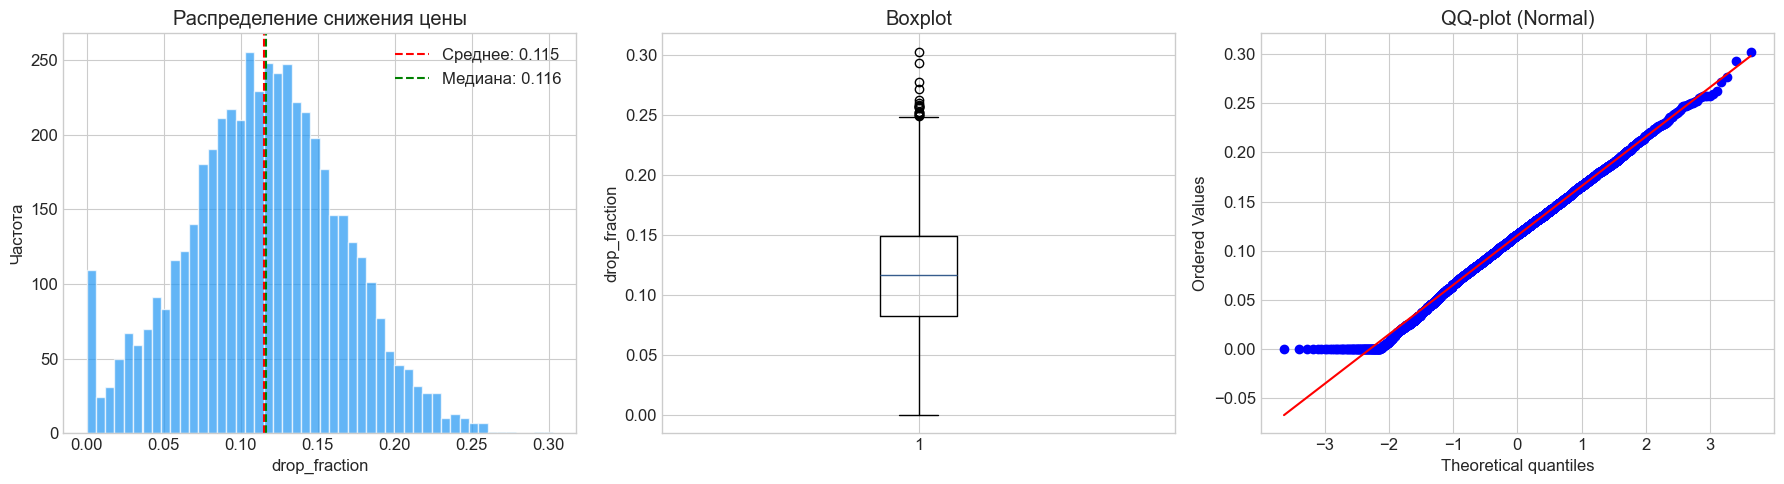


Статистики drop_fraction:
  Mean:     0.1153
  Median:   0.1163
  Std:      0.0504
  Skewness: -0.0128
  Kurtosis: -0.1415


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма
axes[0].hist(df['drop_fraction'], bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
axes[0].axvline(df['drop_fraction'].mean(), color='red', linestyle='--', label=f'Среднее: {df["drop_fraction"].mean():.3f}')
axes[0].axvline(df['drop_fraction'].median(), color='green', linestyle='--', label=f'Медиана: {df["drop_fraction"].median():.3f}')
axes[0].set_xlabel('drop_fraction')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение снижения цены')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['drop_fraction'], vert=True)
axes[1].set_ylabel('drop_fraction')
axes[1].set_title('Boxplot')

# QQ-plot
stats.probplot(df['drop_fraction'], dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot (Normal)')

plt.tight_layout()
plt.savefig('../artifacts/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Статистики
print(f'\nСтатистики drop_fraction:')
print(f'  Mean:     {df["drop_fraction"].mean():.4f}')
print(f'  Median:   {df["drop_fraction"].median():.4f}')
print(f'  Std:      {df["drop_fraction"].std():.4f}')
print(f'  Skewness: {df["drop_fraction"].skew():.4f}')
print(f'  Kurtosis: {df["drop_fraction"].kurtosis():.4f}')

## 5. Корреляции и зависимости

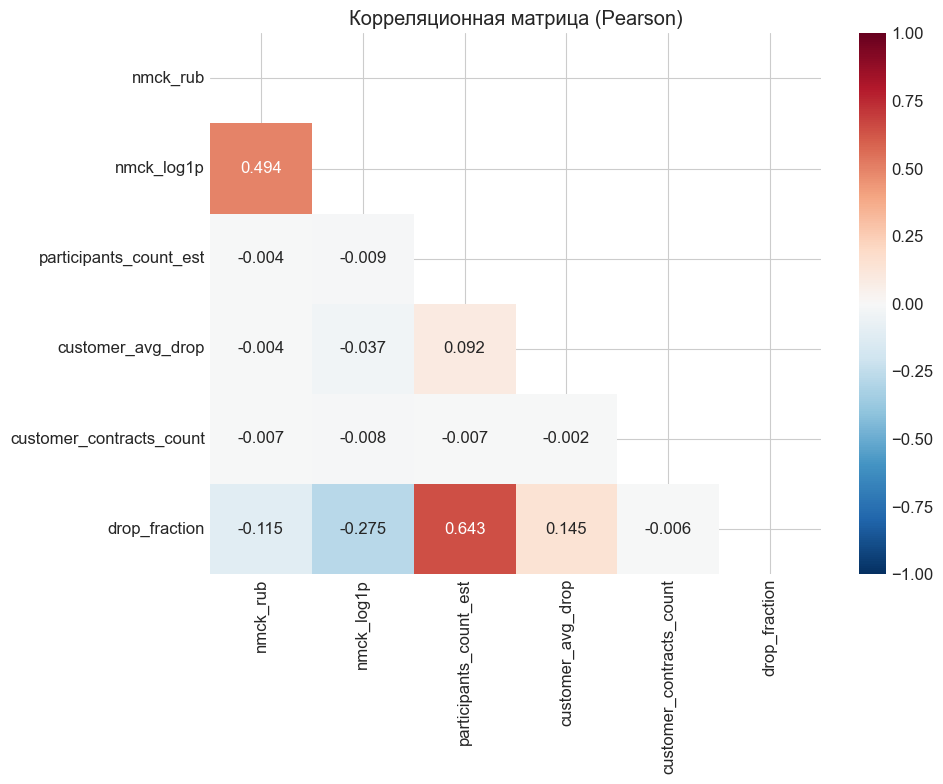

In [9]:
# Корреляционная матрица
num_features = ['nmck_rub', 'nmck_log1p', 'participants_count_est', 
                'customer_avg_drop', 'customer_contracts_count', 'drop_fraction']
corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Корреляционная матрица (Pearson)')
plt.tight_layout()
plt.savefig('../artifacts/eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/g5/g_jqht053_j0x27fn094b_0r0000gn/T/ipykernel_96445/2632464955.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(top_groups.values, labels=top_groups.index)


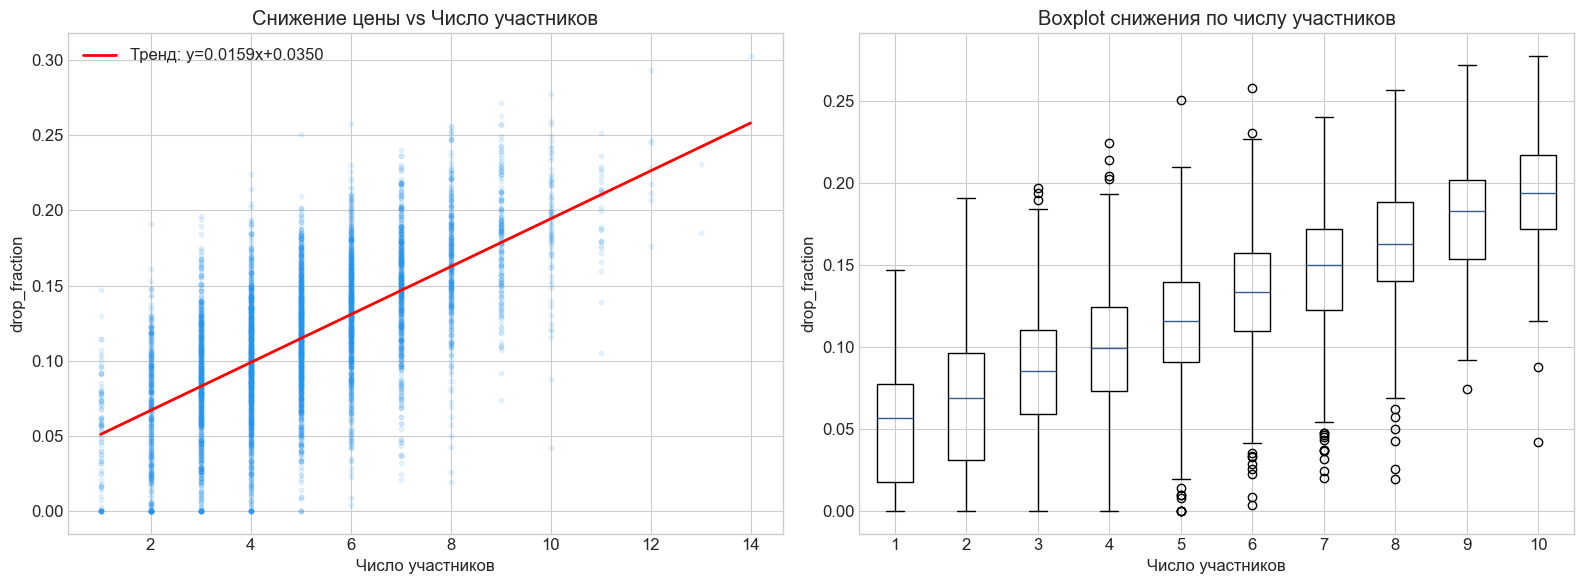

In [10]:
# Зависимость drop от числа участников
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
axes[0].scatter(df['participants_count_est'], df['drop_fraction'], 
               alpha=0.1, s=10, color='#2196F3')
# Тренд
z = np.polyfit(df['participants_count_est'], df['drop_fraction'], 1)
p = np.poly1d(z)
x_trend = np.linspace(1, df['participants_count_est'].max(), 100)
axes[0].plot(x_trend, p(x_trend), 'r-', linewidth=2, label=f'Тренд: y={z[0]:.4f}x+{z[1]:.4f}')
axes[0].set_xlabel('Число участников')
axes[0].set_ylabel('drop_fraction')
axes[0].set_title('Снижение цены vs Число участников')
axes[0].legend()

# Boxplot по участникам
groups = df.groupby('participants_count_est')['drop_fraction'].apply(list)
top_groups = groups[groups.index <= 10]
axes[1].boxplot(top_groups.values, labels=top_groups.index)
axes[1].set_xlabel('Число участников')
axes[1].set_ylabel('drop_fraction')
axes[1].set_title('Boxplot снижения по числу участников')

plt.tight_layout()
plt.savefig('../artifacts/eda_drop_vs_participants.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/g5/g_jqht053_j0x27fn094b_0r0000gn/T/ipykernel_96445/2637460426.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='procedure_type', y='drop_fraction', order=order, ax=ax, palette='viridis')


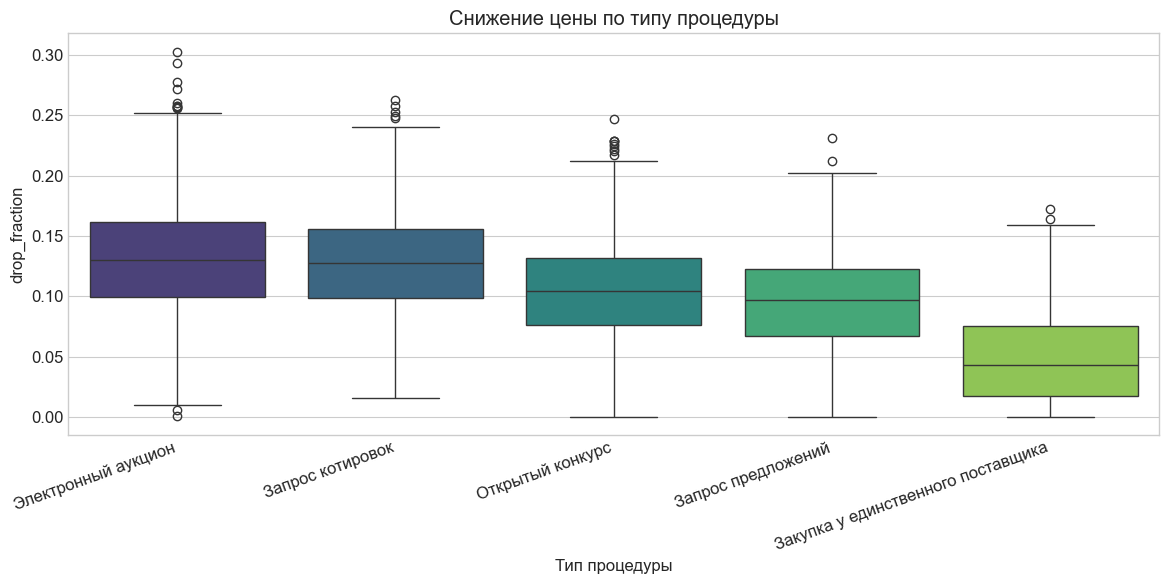

In [11]:
# Снижение по типу процедуры
fig, ax = plt.subplots(figsize=(12, 6))
order = df.groupby('procedure_type')['drop_fraction'].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='procedure_type', y='drop_fraction', order=order, ax=ax, palette='viridis')
ax.set_xlabel('Тип процедуры')
ax.set_ylabel('drop_fraction')
ax.set_title('Снижение цены по типу процедуры')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../artifacts/eda_drop_by_procedure.png', dpi=150, bbox_inches='tight')
plt.show()

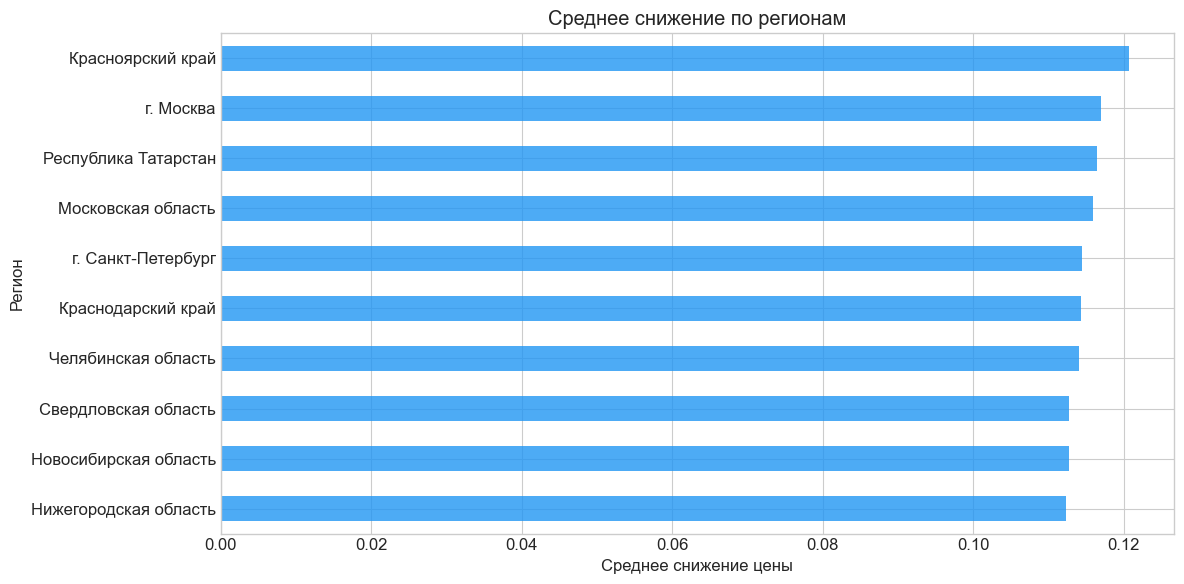

In [12]:
# Снижение по регионам
fig, ax = plt.subplots(figsize=(12, 6))
region_stats = df.groupby('region')['drop_fraction'].agg(['mean', 'count']).sort_values('mean', ascending=True)
region_stats['mean'].plot(kind='barh', ax=ax, color='#2196F3', alpha=0.8)
ax.set_xlabel('Среднее снижение цены')
ax.set_ylabel('Регион')
ax.set_title('Среднее снижение по регионам')
plt.tight_layout()
plt.savefig('../artifacts/eda_drop_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/g5/g_jqht053_j0x27fn094b_0r0000gn/T/ipykernel_96445/1817088741.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='fz_type', y='drop_fraction', ax=ax, palette='Set2')


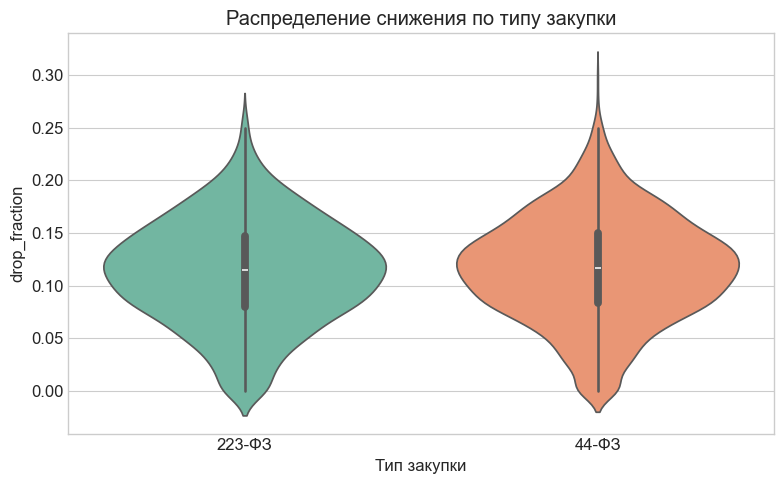

In [13]:
# Снижение по типу закупки
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x='fz_type', y='drop_fraction', ax=ax, palette='Set2')
ax.set_xlabel('Тип закупки')
ax.set_ylabel('drop_fraction')
ax.set_title('Распределение снижения по типу закупки')
plt.tight_layout()
plt.savefig('../artifacts/eda_drop_by_fz_type.png', dpi=150, bbox_inches='tight')
plt.show()

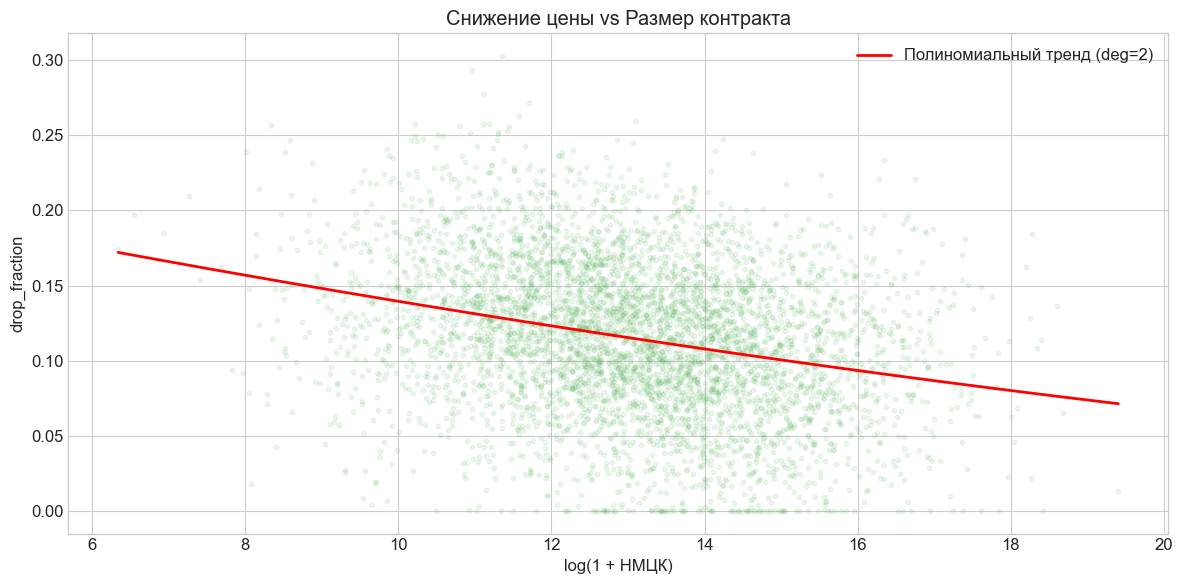

In [14]:
# Зависимость от НМЦК
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df['nmck_log1p'], df['drop_fraction'], alpha=0.1, s=10, color='#4CAF50')
z = np.polyfit(df['nmck_log1p'], df['drop_fraction'], 2)
p = np.poly1d(z)
x_trend = np.linspace(df['nmck_log1p'].min(), df['nmck_log1p'].max(), 100)
ax.plot(x_trend, p(x_trend), 'r-', linewidth=2, label='Полиномиальный тренд (deg=2)')
ax.set_xlabel('log(1 + НМЦК)')
ax.set_ylabel('drop_fraction')
ax.set_title('Снижение цены vs Размер контракта')
ax.legend()
plt.tight_layout()
plt.savefig('../artifacts/eda_drop_vs_nmck.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Выводы и рекомендации

### Основные выводы:

1. **Целевая переменная** `drop_fraction` имеет правостороннее асимметричное распределение со средним ~0.12 и медианой ~0.10

2. **Число участников** — самый сильный предиктор снижения цены (корреляция ~0.6). Больше участников → больше снижение

3. **Тип процедуры** значимо влияет: запрос котировок показывает наибольшее среднее снижение, закупка у единственного поставщика — минимальное

4. **Размер НМЦК** слабо влияет на снижение — крупные контракты показывают незначительно меньшее снижение

5. **Пропуски отсутствуют** — данные качественные, не требуют импутации

6. **Выбросы**: ~5% записей имеют аномально высокое снижение (>40%), их стоит сохранить как реальные случаи ценового демпинга

### Рекомендации для модели:

- Использовать **gradient boosting** (CatBoost / XGBoost) — хорошо работает с категориальными признаками
- `customer_inn` — high-cardinality категориальный признак, CatBoost обрабатывает его нативно
- Не нужна нормализация для деревьев, но стоит сделать `log1p` для НМЦК
- Стратифицированное разбиение по `procedure_type` для train/test